In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
dataSpline = pd.read_csv("../../DataSpline.csv")

In [8]:
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

x_scaler = StandardScaler().fit(dataSpline[PREDICTORS])
y_scaler = StandardScaler().fit(dataSpline[[TARGET]])

data_norm = pd.DataFrame()
data_norm[PREDICTORS] = x_scaler.transform(dataSpline[PREDICTORS])
data_norm[TARGET] = y_scaler.transform(dataSpline[[TARGET]]).ravel()


def get_XY(data, time_steps, units, output_dim):
    total_samples = (len(data) - time_steps) // time_steps

    X = []
    Y = []
    
    for i in range(total_samples):
        start_idx = i * time_steps
        end_idx = start_idx + time_steps

        X_seq = data.iloc[start_idx:end_idx][PREDICTORS].values  # shape: (time_steps, features)
        Y_target = data.iloc[end_idx][TARGET]  # escalar

        X.append(X_seq)
        Y.append(Y_target)

    X = np.array(X)  # shape: (batch, time_steps, features)
    Y =  Y = np.array(Y).reshape(-1, 1).repeat(output_dim, axis=1)  # shape (batch, output_dim)
    h0 = np.full((X.shape[0], units), fill_value=Y[0]) # shape (batch, units)

    print(f"Shape X (batch, time_steps, features): {X.shape}")
    print(f"Shape Y (batch, output_dim): {Y.shape}")
    print(f"Shape h0 (batch, units): {h0.shape}")
    
    return X, Y, h0

In [6]:
import seaborn as sns

def PlotOut(valuer):
    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=False)

    datasets = [
        ('Treinamento', valuer.train_samples_y, valuer.train_pred),
        ('Validação', valuer.val_samples_y, valuer.val_pred),
        ('Teste', valuer.test_samples_y, valuer.test_pred)
    ]

    times = [
        np.arange(len(valuer.train_samples_y)),
        np.arange(len(valuer.val_samples_y)),
        np.arange(len(valuer.test_samples_y))
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        # Garante que são vetores 1D
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)

        sns.lineplot(x=times[i], y=y_true, ax=axs[i], marker="o", label="Amostras Reais", linewidth=2)
        sns.lineplot(x=times[i], y=y_pred, ax=axs[i], marker="o", label="Valores preditos", linewidth=2)

        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Tempo')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()  
    
    path = f"./content/models/{valuer.fileName}.png"
    fig.savefig(path)    

In [ ]:
PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    predictor_colors = plt.cm.tab10.colors
    target_colors = plt.cm.Set2.colors

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot preditores no eixo esquerdo (sem interpolação)
    for i, preds in enumerate(PREDICTORS):
        ax1.plot(df.index, df[preds], marker="o", linestyle="None", label=preds,
                 color=predictor_colors[i % len(predictor_colors)],
                 markersize=5)

    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Plot alvos no eixo direito (sem interpolação)
    if PlotOut:
        ax2 = ax1.twinx()
        for i, target in enumerate(TARGET):
            ax2.plot(df.index, df[target], marker="o", linestyle="None", label=target,
                     color=target_colors[i % len(target_colors)],
                     markersize=5)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

    # Legendas
    leg1 = ax1.legend(loc="upper left", title="Preditores")
    ax1.add_artist(leg1)
    if PlotOut:
        ax2.legend(loc="upper right", title="Alvos")

    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)
    plt.show()gráfico
    plt.show()

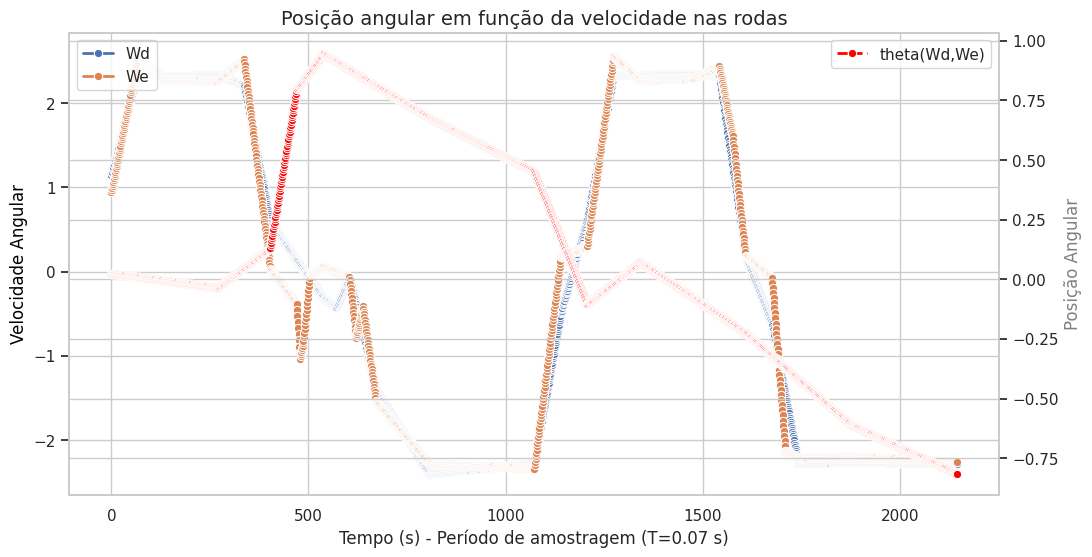

In [10]:
PlotTimeSeries(dataSpline)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from keras import layers, models, regularizers, initializers, optimizers
from keras.callbacks import EarlyStopping
from itertools import product

class EvalRNN:
    
    def __init__(self, dataset, epochs, time_steps, act_h, act_o):
        self.epochs = epochs
        self.Dataset = dataset
        self.output_dim = np.size(TARGET)
        self.time_steps = time_steps
        self.act_h = act_h
        self.act_o = act_o
        self.better_metrics = {}


    def SplitData(self, units):
        self.units = units
                 
        train_data, test_data = train_test_split(self.Dataset, test_size=0.25, shuffle=False)
        train_data, val_data = train_test_split(train_data, test_size=0.15, shuffle=False)
                
        self.train_samples_x, self.train_samples_y, self.h0_train = get_XY(train_data, self.time_steps, units, self.output_dim)       
        self.val_samples_x, self.val_samples_y, self.h0_val = get_XY(val_data, self.time_steps, units, self.output_dim)
        self.test_samples_x, self.test_samples_y, self.h0_test = get_XY(test_data, self.time_steps, units, self.output_dim)

        self.time_steps = self.train_samples_x.shape[1]
        self.features = self.train_samples_x.shape[2]
        
    def BuildModel(self, hidden_sizes, param_reg):
        initializer = initializers.RandomUniform(minval=-0.5,
                                                maxval=0.5,
                                                # seed=np.random.randint(1, 10000)
                                                )
        regularizer = regularizers.L2(param_reg)
        inputs = layers.Input((self.time_steps, self.features))
        initial_state = layers.Input((self.units,))

        # Primeira camada RNN com estado inicial
        rnn_layer = layers.SimpleRNN(
            hidden_sizes[0],
            activation=self.act_h,
            kernel_regularizer=regularizer,
            kernel_initializer=initializer,
            return_sequences=(len(hidden_sizes) > 1)  
        )(inputs, initial_state=initial_state)

        # Demais camadas RNN
        for size in hidden_sizes[1:-1]:
            rnn_layer = layers.SimpleRNN(
                size,
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=True 
            )(rnn_layer)

        # Última camada RNN
        if len(hidden_sizes) > 1:
            rnn_layer = layers.SimpleRNN(
                hidden_sizes[-1],
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=False  
            )(rnn_layer)
       
       # Output mlp layer
        output = layers.Dense(self.output_dim,
                            activation=self.act_o,
                            kernel_regularizer=regularizer,
                            kernel_initializer=initializer)(rnn_layer)
        
        model = models.Model([inputs] + [initial_state], output)
        return(model)
    
    def CompileModel(self, model, lr):
        model.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr))
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.fit(
            [self.train_samples_x, self.h0_train],
            self.train_samples_y,
            epochs=self.epochs,
            validation_data=([self.val_samples_x, self.h0_val], self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            shuffle=False   
        )
    
    def ComputeMetrics(self, model):
        self.train_pred = np.squeeze(model.predict([self.train_samples_x, self.h0_train]))
        self.val_pred = np.squeeze(model.predict([self.val_samples_x, self.h0_val]))
        self.test_pred = np.squeeze(model.predict([self.test_samples_x, self.h0_test]))

        self.train_pred_denorm = y_scaler.inverse_transform(self.train_pred.reshape(-1, 1)).squeeze()
        self.val_pred_denorm = y_scaler.inverse_transform(self.val_pred.reshape(-1, 1)).squeeze()
        self.test_pred_denorm = y_scaler.inverse_transform(self.test_pred.reshape(-1, 1)).squeeze()

        self.train_samples_y_denorm = y_scaler.inverse_transform(self.train_samples_y.reshape(-1, 1)).squeeze()
        self.val_samples_y_denorm = y_scaler.inverse_transform(self.val_samples_y.reshape(-1, 1)).squeeze()
        self.test_samples_y_denorm = y_scaler.inverse_transform(self.test_samples_y.reshape(-1, 1)).squeeze()
            

        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })

    def SaveModelWeights(self, model):
        path = f"./content/models/{self.fileName}.weights.h5"
        open(path,'w').close()
        model.save_weights(path) 

    def LoopWeights(self, model, run_times, lr, boundarie, sort_by, idx):
        better_model = 0
        save = False

        for i in range(run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            self.CompileModel(model, lr)
            metrics = self.ComputeMetrics(model)
            
            if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
                self.fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(model)
                self.better_metrics[self.fileName] = metrics
                better_model += 1
                save = True
        return(save)

    def Evaluate(self, hidden_sizes, regularizers, learning_rate, run_times, boundarie, sort_by):
        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinacao{count}: {header}")
            
            self.SplitData(units=hidden_size[0])        
            model = self.BuildModel(hidden_size, reg)
            
            if (self.LoopWeights(model, run_times, lr, boundarie, sort_by, f"{count}") == True):        
                self.DisplayBetterResults(header, sort_by, f"{count}")
                PlotOut(self)
                
        self.better_metrics = {}
  
                
    def DisplayBetterResults(self, header, sort_by, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'./content/results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)            
       

2025-06-03 01:30:59.661713: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 01:31:00.653644: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 01:31:01.273943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748914262.288157   96286 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748914262.587073   96286 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748914263.988141   96286 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [5]:
Valuer = EvalRNN(dataset = data_norm,
                epochs = 1000,
                time_steps = 2,
                act_h = 'tanh',
                act_o = 'sigmoid',
                )        

Testando combinacao1: Hidden Size=[30], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 30)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 30)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 30)


2025-06-03 01:31:30.197295: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


+++++++++++ [1] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
+++++++++++ [1] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
+++++++++++ [1] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [1] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
+++++++++++ [1] | 5 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [1] | 6 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
+++++++++++ [1] | 7 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 1

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_1_0,0.599311,0.197395,2.452368,0.444291,-40.206439,5.096273,1.774695,2.257493,-45.117459,0.391205,1.628653,0.625464
model_1_1,0.613577,0.190367,2.372078,0.436310,-40.548130,5.138532,1.782726,2.266833,-43.992934,0.381666,1.588911,0.617791
model_1_2,0.620002,0.187202,1.730336,0.432668,-40.496440,5.132139,1.780120,2.265423,-31.046622,0.271845,1.385393,0.521388
model_1_4,0.626773,0.183866,1.949550,0.428796,-40.427876,5.123659,1.779693,2.263550,-35.382544,0.308626,1.440473,0.555541
model_1_5,0.627345,0.183584,2.111286,0.428467,-40.507676,5.133529,1.781805,2.265729,-38.939803,0.338801,1.480802,0.582066
model_1_3,0.635846,0.179396,1.976002,0.423552,-40.734606,5.161595,1.786888,2.271914,-35.779108,0.311990,1.426987,0.558560
model_1_7,0.636896,0.178879,1.366095,0.422941,-40.504686,5.133159,1.780694,2.265648,-24.302072,0.214632,1.288595,0.463284
model_1_6,0.640398,0.177154,1.372500,0.420896,-40.704042,5.157815,1.785143,2.271082,-24.257214,0.214252,1.279903,0.462873
model_1_8,0.641633,0.176545,1.320105,0.420173,-40.531501,5.136475,1.780058,2.266379,-23.788542,0.210276,1.281880,0.458559


DataFrame salvo em ./content/results/metrics_1


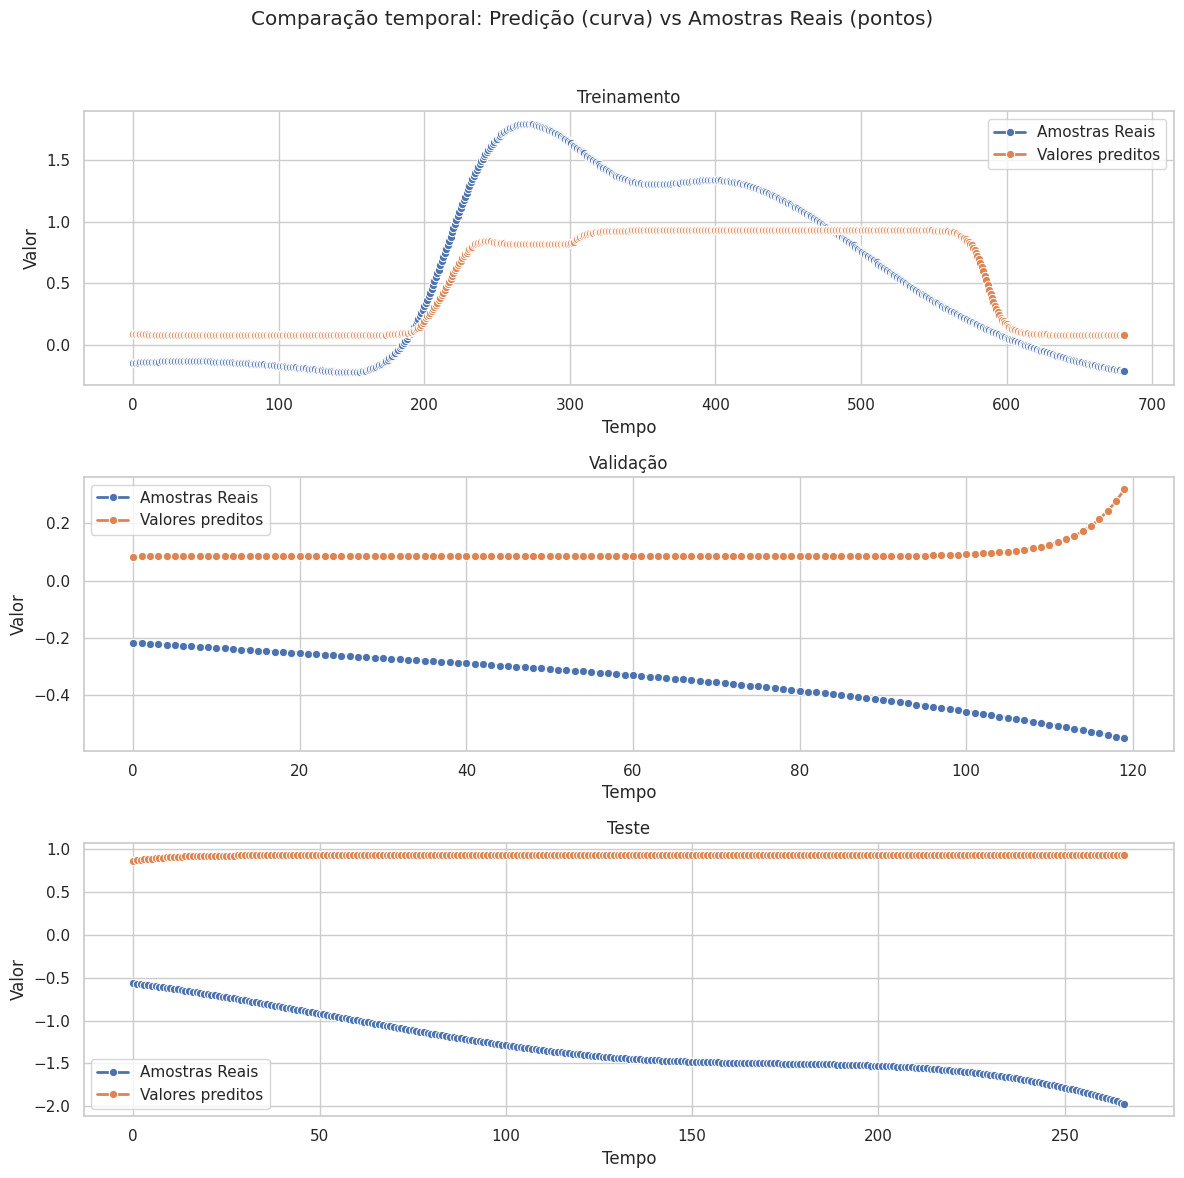

Testando combinacao2: Hidden Size=[35], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 35)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 35)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 35)
+++++++++++ [2] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [2] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [2] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
+++++++++++ [2] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
4/4 ━━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_0,0.547010,0.223160,2.639935,0.472398,-39.158711,4.966693,1.748305,2.228608,-48.723632,0.421795,1.762649,0.649458
model_1_0,0.599311,0.197395,2.452368,0.444291,-40.206439,5.096273,1.774695,2.257493,-45.117459,0.391205,1.628653,0.625464
model_2_7,0.613564,0.190373,1.170536,0.436317,-40.943289,5.187404,1.789850,2.277587,-21.543335,0.191231,1.234646,0.437299
model_1_1,0.613577,0.190367,2.372078,0.436310,-40.548130,5.138532,1.782726,2.266833,-43.992934,0.381666,1.588911,0.617791
model_1_2,0.620002,0.187202,1.730336,0.432668,-40.496440,5.132139,1.780120,2.265423,-31.046622,0.271845,1.385393,0.521388
model_1_4,0.626773,0.183866,1.949550,0.428796,-40.427876,5.123659,1.779693,2.263550,-35.382544,0.308626,1.440473,0.555541
model_2_5,0.627070,0.183720,1.190749,0.428625,-41.133943,5.210983,1.796020,2.282758,-22.391251,0.198423,1.235825,0.445447
model_1_5,0.627345,0.183584,2.111286,0.428467,-40.507676,5.133529,1.781805,2.265729,-38.939803,0.338801,1.480802,0.582066
model_2_2,0.628819,0.182858,2.033833,0.427619,-40.621791,5.147642,1.784465,2.268842,-43.562324,0.378013,1.555771,0.614828
model_2_6,0.630696,0.181933,1.294059,0.426536,-40.763543,5.165174,1.787438,2.272702,-24.086398,0.212803,1.286163,0.461306


DataFrame salvo em ./content/results/metrics_2


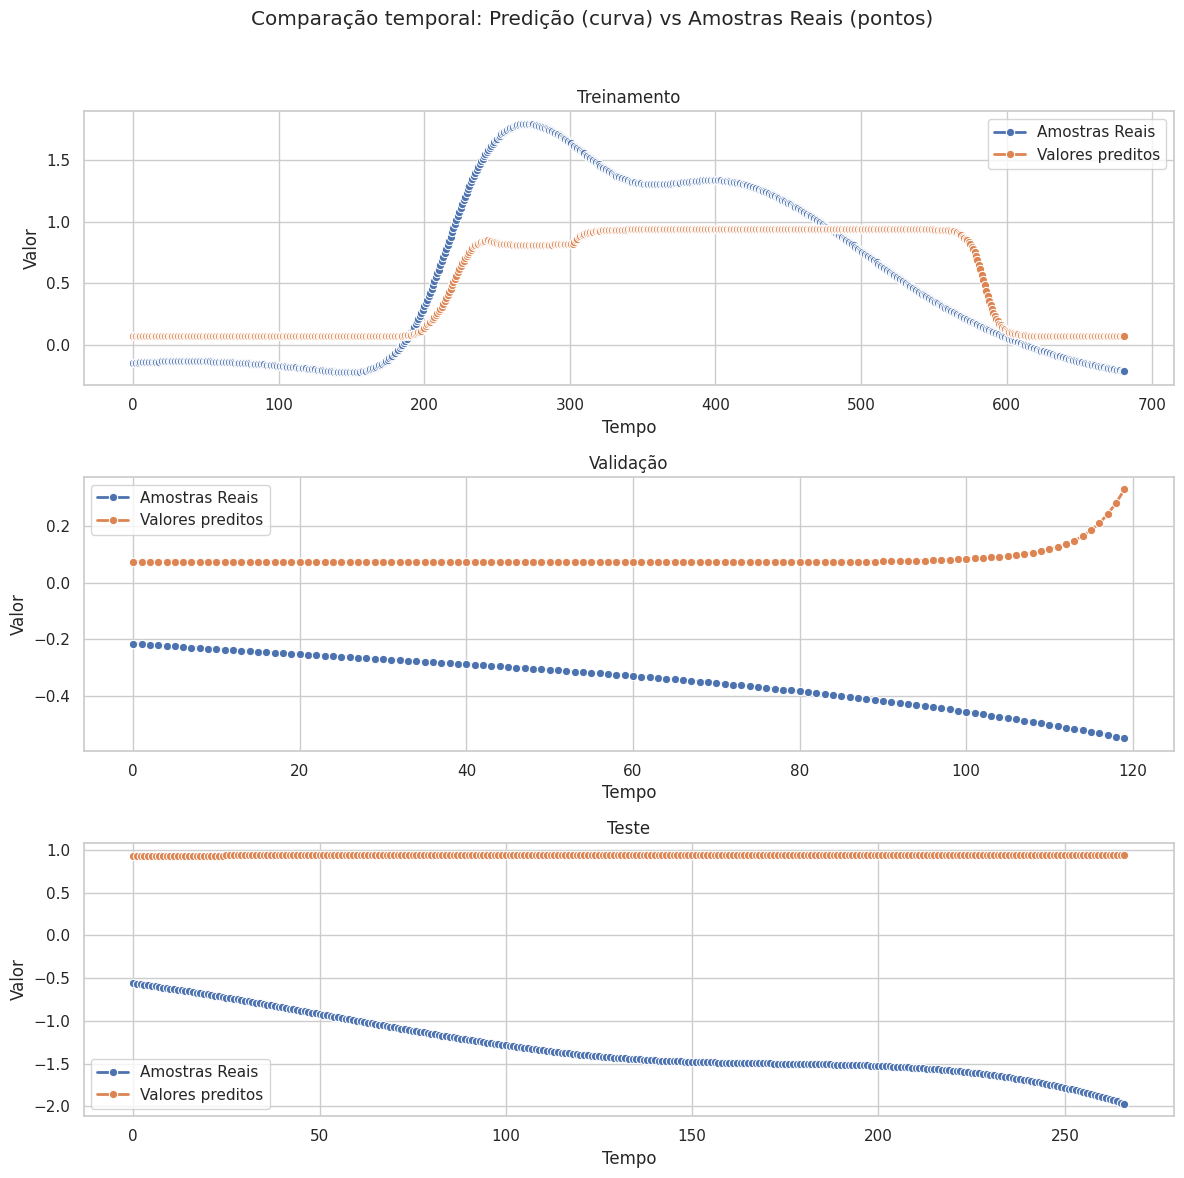

Testando combinacao3: Hidden Size=[40], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 40)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 40)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 40)
+++++++++++ [3] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
+++++++++++ [3] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [3] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [3] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
4/4 ━━━━

In [6]:
Valuer.Evaluate(hidden_sizes = [[30], [35], [40], [45], [50]],
            regularizers=[0.2],
            learning_rate=[0.01],
            run_times = 10, 
            boundarie = 0.5,
            sort_by = 'r2_training',
) 